# lambda_data sweep (stride_x=stride_t=10)

Sweeps `lam_data ? {0.1, 0.5, 1, 5, 10}` under fixed controls.

**Controls**
- `stride_x = 10`, `stride_t = 10`
- `noise=0.7`, `nu=0.02`
- `steps=8000`, `batch_size=1000`, `lr=0.001`
- `lam_pde=0.5`, `lam_tv=0`, `lam_reg=0`

**Dependents (same table outputs)**
- Final `loss_data`, `loss_pde`
- `w_u`, `w_ux`, `w_uxx`, `w_prod` from `eql.readout.weight`
- `M01`, `M10` from `eql.effective_quadratic_matrix(symmetrize=False)`


In [2]:
import sys

sys.path.append('..')  # add project root

import numpy as np
import torch
import matplotlib.pyplot as plt

from prog import mlps, featlib, trainer, hlprs
import Datasets.matconv as mc

SEED = 1432
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cpu')


In [3]:
# Controls

steps = 8000
log_every = 1000

noise = 0.7
nu = 0.02

stride_x = 10
stride_t = 10

lr = 1e-3
batch_size = 1000

lam_pde = 0.5
lam_tv = 0.0
lam_reg = 0.0

selected_derivs = ('u','u_x','u_xx')

lam_data_values = [0.1, 0.5, 1.0, 5.0, 10.0]

# Dataset partitioning controls
part_num = 1
which_part = 1


In [4]:
# Build dataset (fixed stride_x=stride_t=10)

partitions = mc.build_dataset_from_burgers(
    noise_level=noise,
    nu=nu,
    stride_t=stride_t,
    stride_x=stride_x,
    seed=SEED,
    quantile_splits=part_num,
    return_partitions=True,
)

key = [k for k in partitions if k.startswith(f'Q{which_part}:')][0]
t_np, x_np, y_np, y_noisy_np, _N = partitions[key]

# torch tensors

t_torch       = torch.from_numpy(t_np).to(device)
x_torch       = torch.from_numpy(x_np).to(device)
y_clean_torch = torch.from_numpy(y_np).to(device)
y_noisy_torch = torch.from_numpy(y_noisy_np).to(device)

print('N points:', t_np.shape[0])
print('x_unique:', len(np.unique(x_np)), 't_unique:', len(np.unique(t_np)))


N points: 676
x_unique: 26 t_unique: 26


In [9]:
def run_once(lam_data: float):
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    u_model = mlps.SimpleMLP(n_layers=4, hidden_size=64, act=mlps.Sin)
    symnet  = mlps.EQL(in_dim=len(selected_derivs), prod_dim=2, num_layers=1, bias=False)

    train_config = trainer.TrainerConfig(
        lr=lr,
        lambda_pde=lam_pde,
        lambda_reg=lam_reg,
        lambda_tv=lam_tv,
        lambda_data=lam_data,
        selected_derivs=selected_derivs,
        device=device,
    )

    ft = featlib.FeatureTensor(selected_derivs, normalize=False)
    feature_builder = ft.build

    train = trainer.PDETrainer(
        u_model=u_model,
        v_model=symnet,
        cfg=train_config,
        feature_builder=feature_builder,
    )

    loss_dat = []
    loss_pde = []

    for i in range(steps):
        t, x, u_noisy, u_clean = hlprs.make_batch(
            batch_size=batch_size,
            t_torch=t_torch,
            x_torch=x_torch,
            y_clean=y_clean_torch,
            y_noisy=y_noisy_torch,
        )
        out = train.step(t=t, x=x, u_noisy=u_noisy, u_clean=u_clean)
        loss_dat.append(out['loss_data'])
        loss_pde.append(out['loss_pde'])

        if log_every and i % log_every == 0:
            print(f"[lam_data={lam_data:g}] step {i}: data={out['loss_data']:.6e} pde={out['loss_pde']:.6e}")

    w = symnet.readout.weight.detach().cpu().numpy().reshape(-1)
    M = symnet.effective_quadratic_matrix(symmetrize=False).detach().cpu().numpy()
    print(hlprs.snapshot_comp(train.u, stride_x, stride_t, y_noisy_np, y_np, t_np, x_np, snap_no=10)[:0])

    return {
        'lam_data': float(lam_data),
        'loss_data_final': float(loss_dat[-1]),
        'loss_pde_final': float(loss_pde[-1]),
        'w_u': float(w[0]),
        'w_ux': float(w[1]),
        'w_uxx': float(w[2]),
        'w_prod': float(w[-1]),
        'M01': float(M[0,1]),
        'M10': float(M[1,0]),
        'loss_data_curve': loss_dat,
        'loss_pde_curve': loss_pde,
        'readout_weight': w,
        'M_eff': M,
    }


Running lam_data = 0.1
[lam_data=0.1] step 0: data=1.003832e+00 pde=7.057870e-03
[lam_data=0.1] step 1000: data=5.333731e-01 pde=1.551797e-04
[lam_data=0.1] step 2000: data=5.469244e-01 pde=2.268512e-04
[lam_data=0.1] step 3000: data=4.867387e-01 pde=6.638932e-05
[lam_data=0.1] step 4000: data=5.024641e-01 pde=6.960066e-05
[lam_data=0.1] step 5000: data=4.786893e-01 pde=1.036695e-04
[lam_data=0.1] step 6000: data=5.281678e-01 pde=1.615521e-04
[lam_data=0.1] step 7000: data=4.821900e-01 pde=1.867079e-04
max_abs_diff = 0.590051
()
Running lam_data = 0.5
[lam_data=0.5] step 0: data=1.003832e+00 pde=7.057870e-03
[lam_data=0.5] step 1000: data=5.312920e-01 pde=6.922369e-04
[lam_data=0.5] step 2000: data=5.438744e-01 pde=1.633131e-03
[lam_data=0.5] step 3000: data=4.845589e-01 pde=1.135501e-03
[lam_data=0.5] step 4000: data=5.007266e-01 pde=1.103708e-03
[lam_data=0.5] step 5000: data=4.768723e-01 pde=1.195182e-03
[lam_data=0.5] step 6000: data=5.164962e-01 pde=1.746320e-03
[lam_data=0.5] ste

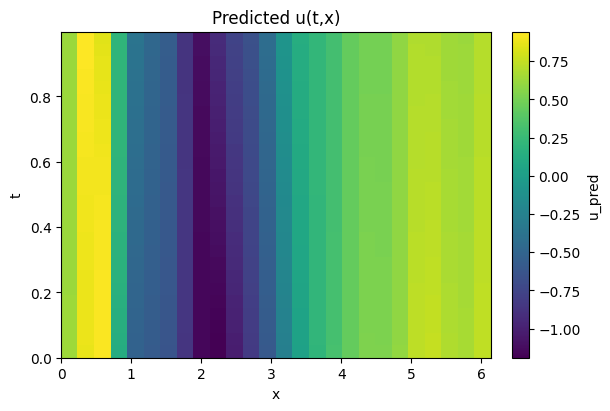

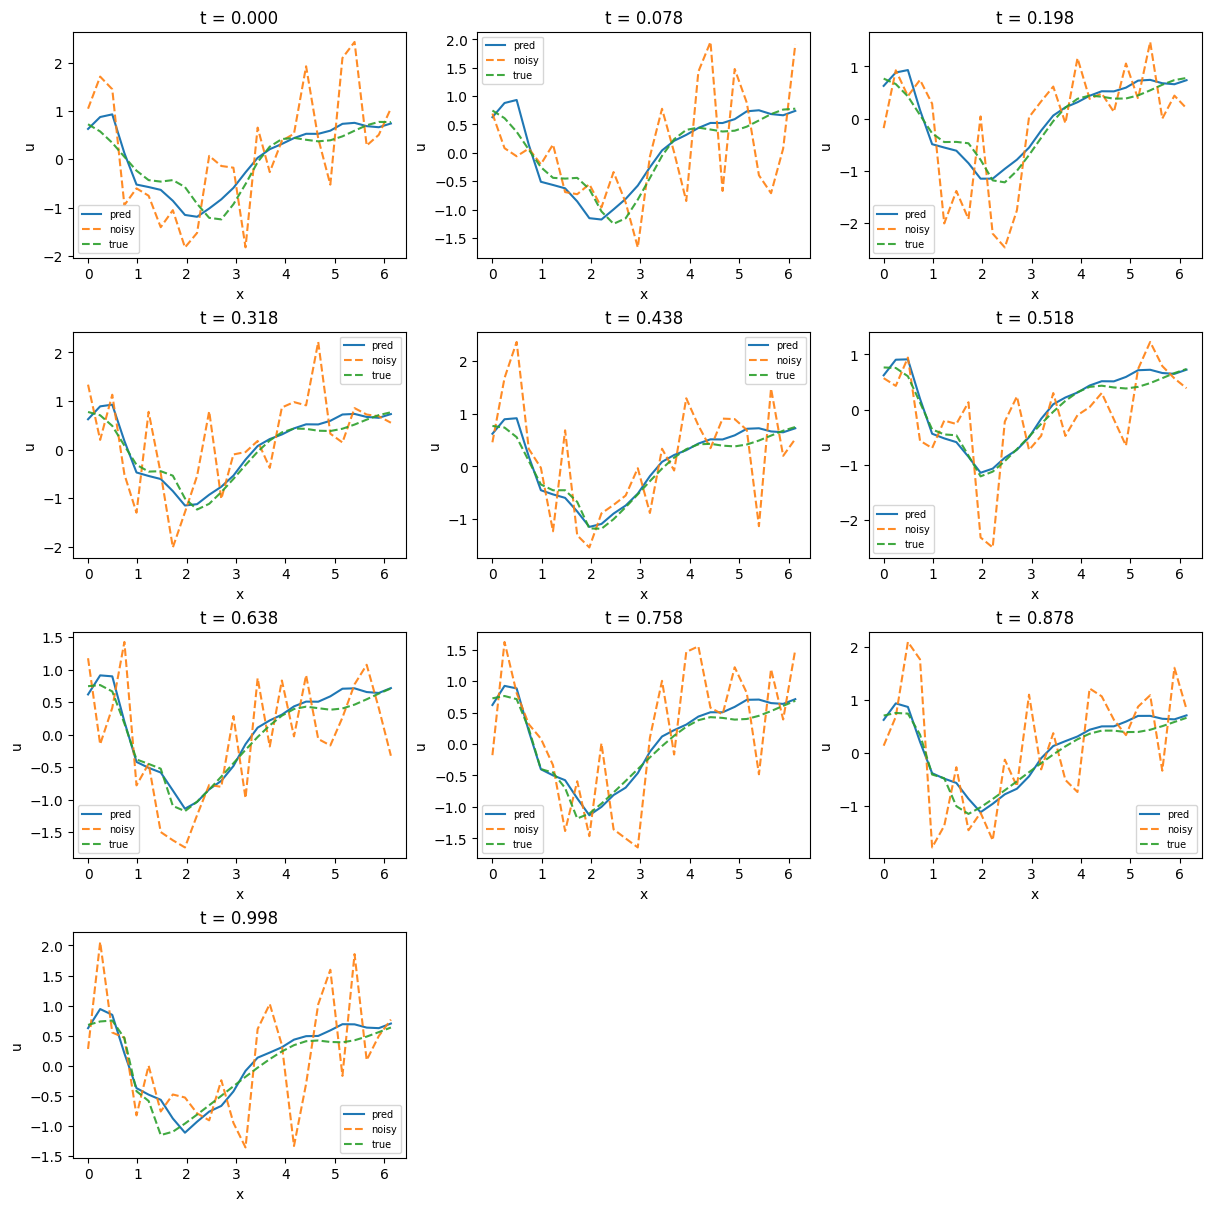

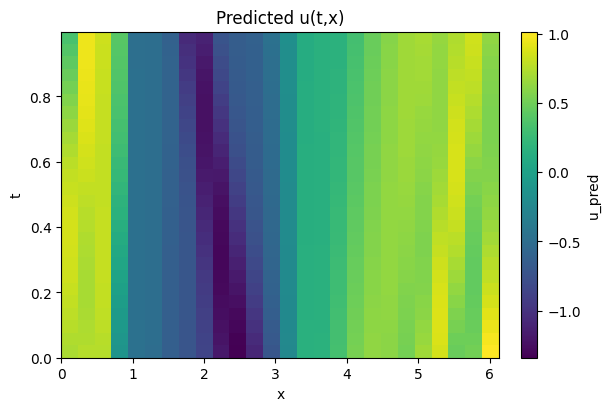

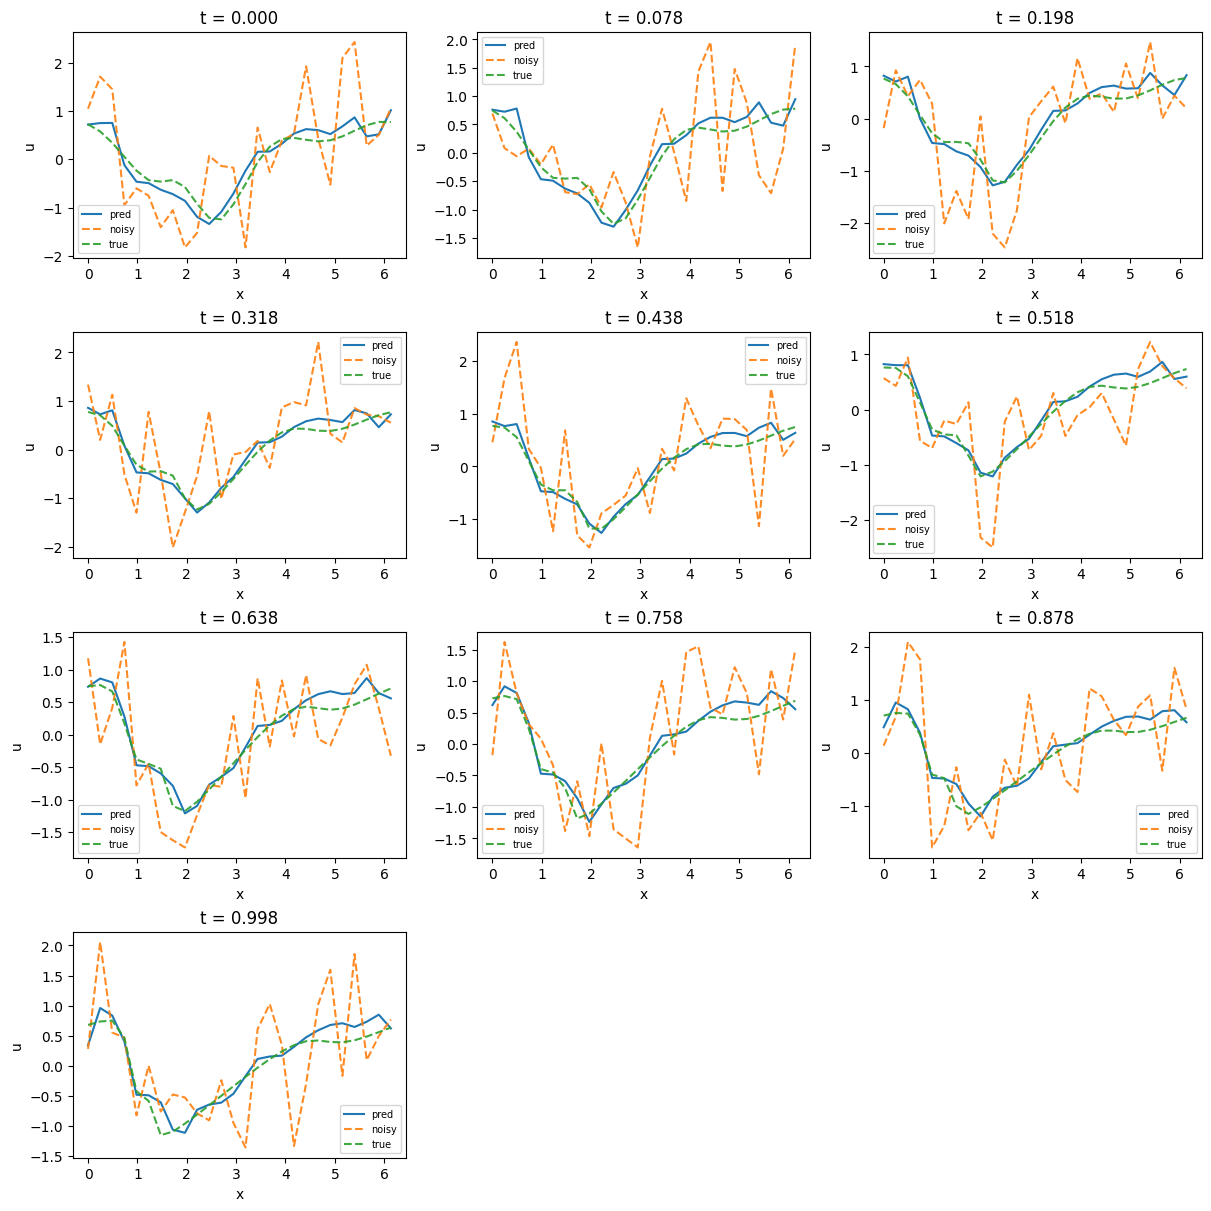

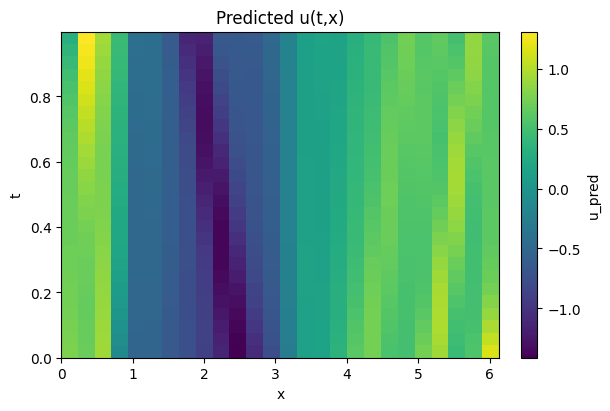

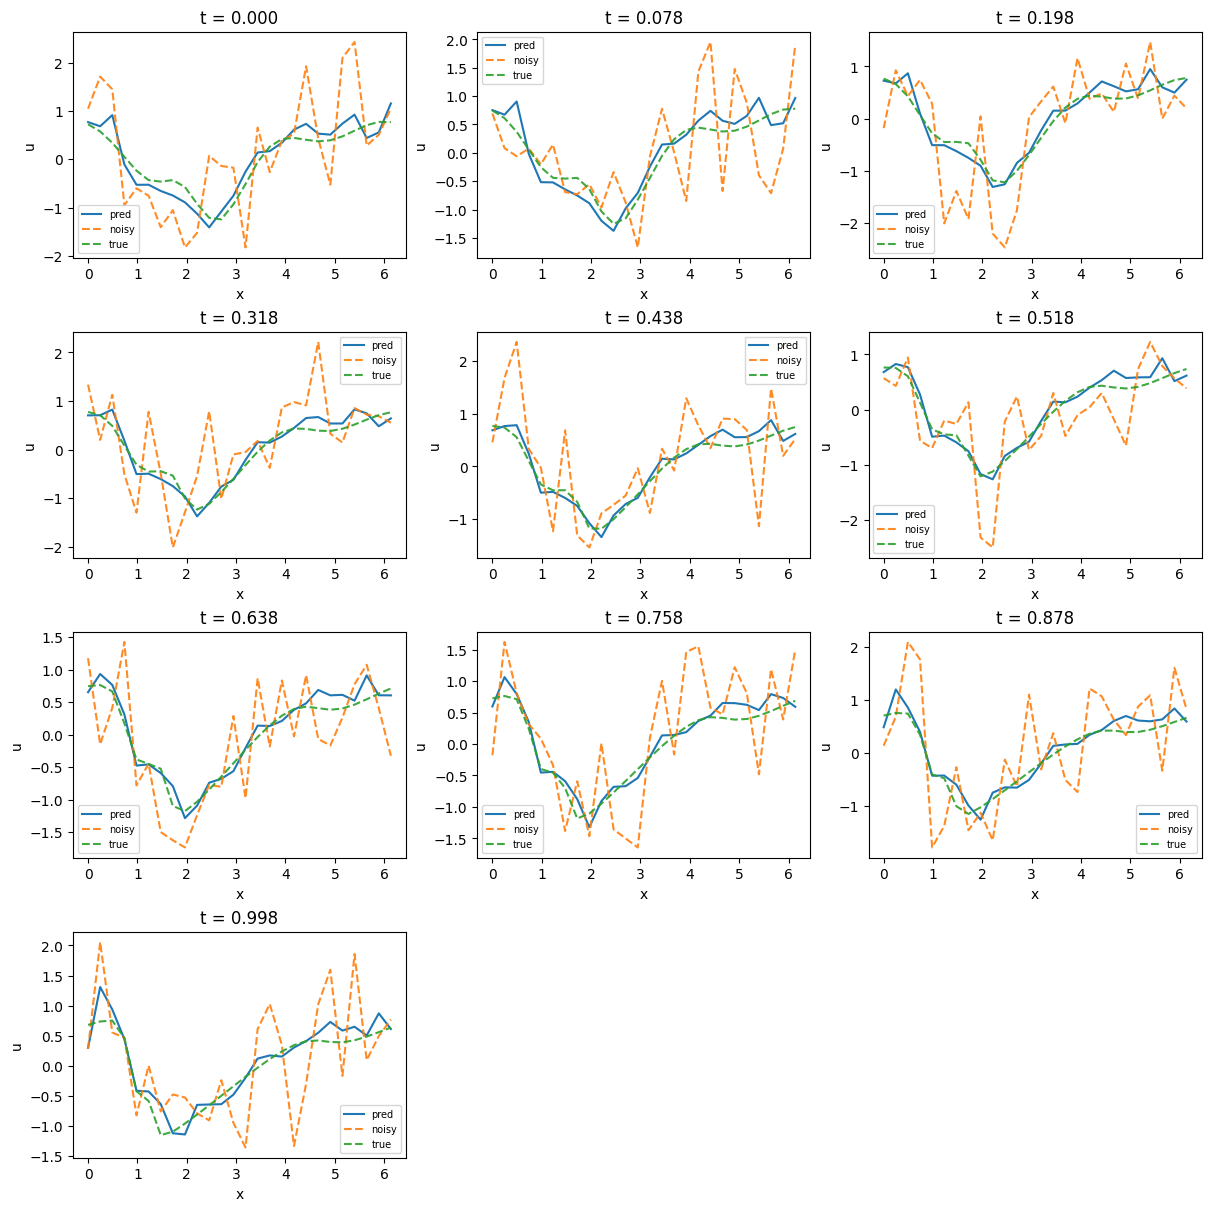

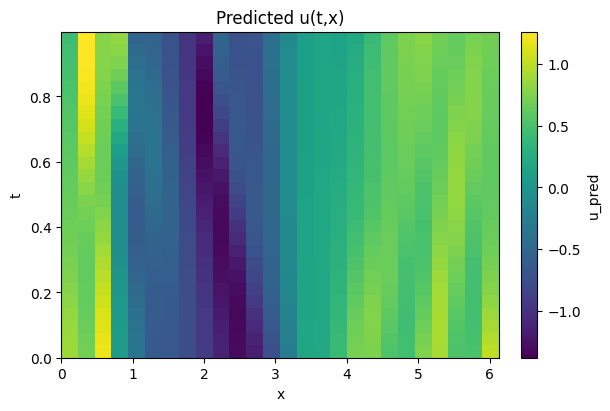

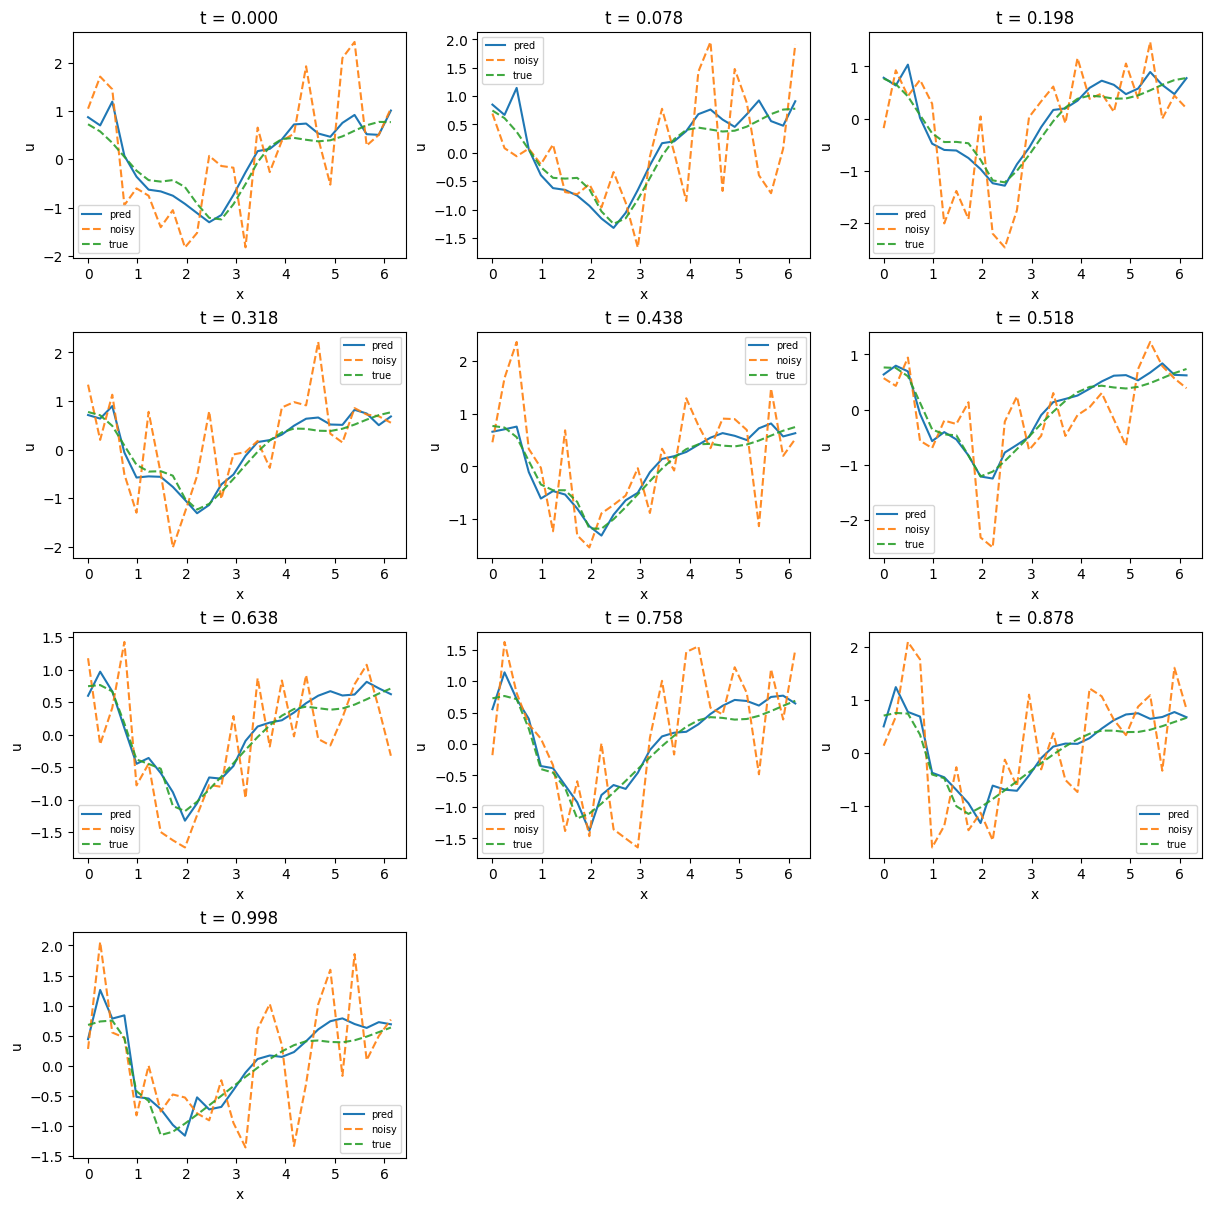

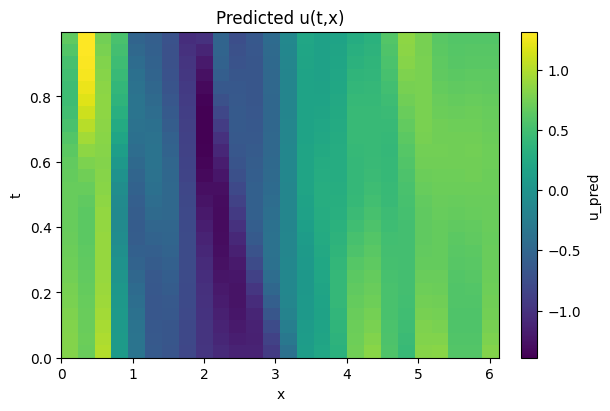

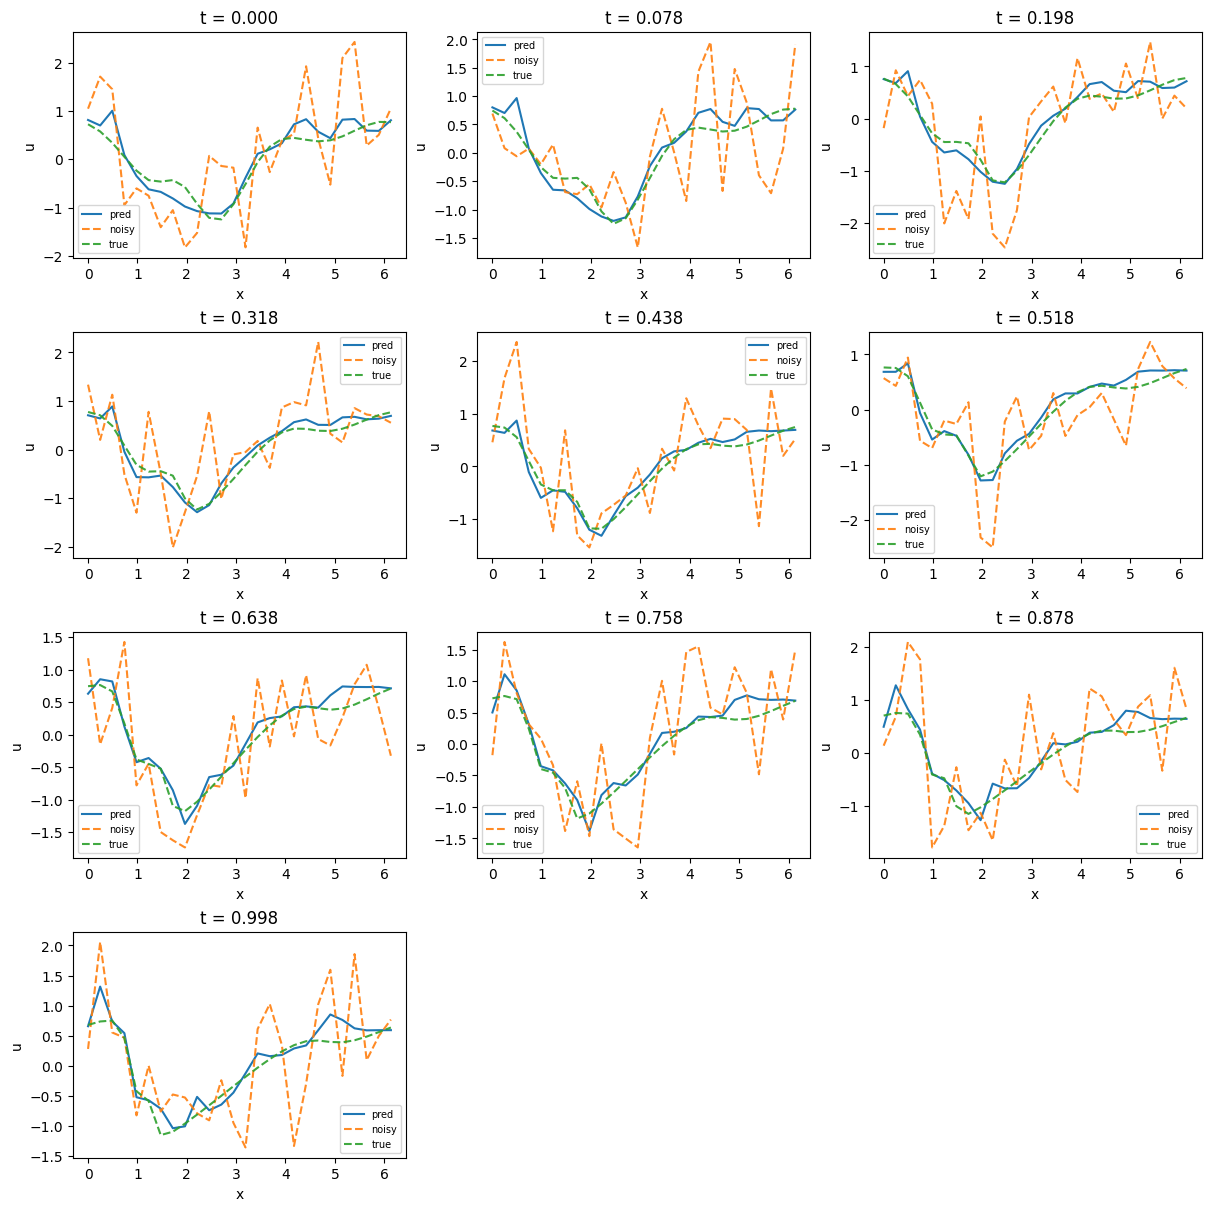

In [10]:
# Run sweep

results = []
for lam_data in lam_data_values:
    print('==============================')
    print('Running lam_data =', lam_data)
    print('==============================')
    results.append(run_once(lam_data))


In [11]:
# Table output

try:
    import pandas as pd
except ImportError:
    pd = None

cols = [
    'lam_data',
    'loss_data_final','loss_pde_final',
    'w_u','w_ux','w_uxx','w_prod',
    'M01','M10'
]

rows = [{k: r[k] for k in cols} for r in results]

if pd is not None:
    df = pd.DataFrame(rows).sort_values(['lam_data']).reset_index(drop=True)
    display(df)
    print('Markdown table (paste into email):')
    print(df.to_markdown(index=False))
else:
    print(rows)


,lam_data,loss_data_final,loss_pde_final,w_u,w_ux,w_uxx,w_prod,M01,M10
0,0.1,0.491158,0.000178,-0.113047,0.078034,-0.007183,-0.112483,-0.025064,-0.037355
1,0.5,0.486361,0.002620,-0.133323,0.027004,-0.004049,-0.557143,-0.599503,0.001148
2,1.0,0.478354,0.007777,-0.351299,0.123650,-0.008817,-0.641997,-0.654303,0.002599
3,5.0,0.468377,0.066171,0.155058,0.176933,-0.024264,-0.647179,-0.610059,-0.020531
4,10.0,0.459680,0.187138,0.058569,0.331093,-0.019775,-0.525547,-0.173080,-0.062836


Markdown table (paste into email):


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

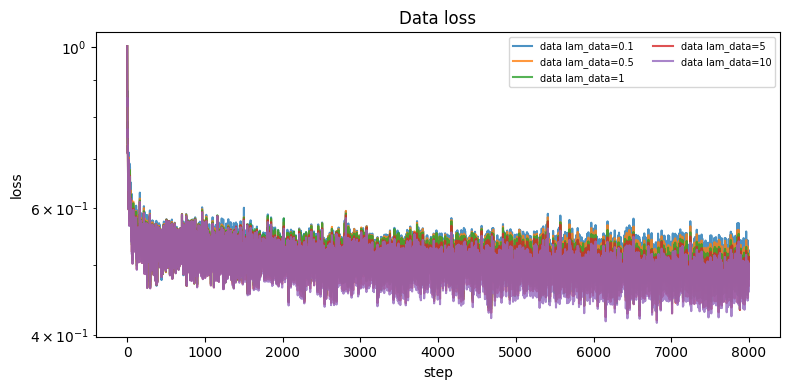

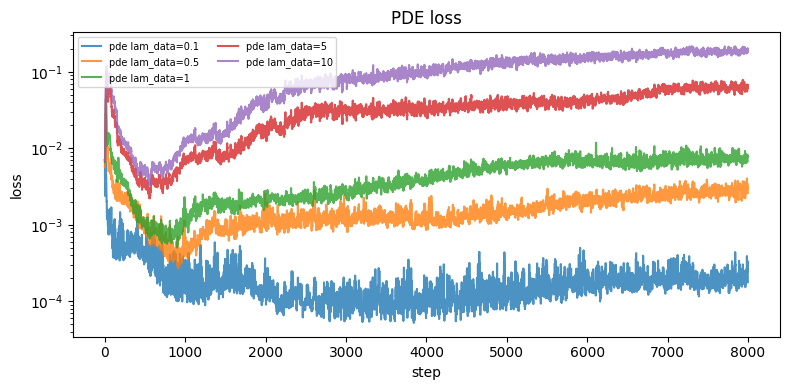

In [12]:
# Plot loss curves (data, pde) per lam_data

plt.figure(figsize=(8,4))
for r in results:
    plt.plot(r['loss_data_curve'], label=f"data lam_data={r['lam_data']:g}", alpha=0.8)
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('loss'); plt.title('Data loss'); plt.legend(fontsize=7, ncols=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(8,4))
for r in results:
    plt.plot(r['loss_pde_curve'], label=f"pde lam_data={r['lam_data']:g}", alpha=0.8)
plt.yscale('log'); plt.xlabel('step'); plt.ylabel('loss'); plt.title('PDE loss'); plt.legend(fontsize=7, ncols=2); plt.tight_layout(); plt.show()
